In [1]:
#INSTALLING 
!pip install -q datasets torch sentencepiece
print("installation done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.5 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 78.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 42.2 MB/s eta 0:00:00:00:0100:01
ERROR: pip's de

In [3]:
import torch
import random
import os
import torch.nn as nn
import unicodedata
import torch.optim as optim
import sentencepiece as spm
import torch.nn.functional as F
from tqdm import tqdm
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset, random_split
print("importing done")

importing done


In [4]:
# LOADING THE DATASET
dataset = load_dataset("Purvaxxx/NMT_DATASET")
Hindi = dataset["hindi"]
Hindi_dataset = Hindi.select(range(25000))
print(Hindi_dataset)

README.md:   0%|          | 0.00/642 [00:00<?, ?B/s]

data/marathi-00000-of-00001.parquet:   0%|          | 0.00/5.81M [00:00<?, ?B/s]

data/bengali-00000-of-00001.parquet:   0%|          | 0.00/15.9M [00:00<?, ?B/s]

data/telugu-00000-of-00001.parquet:   0%|          | 0.00/11.0M [00:00<?, ?B/s]

data/hindi-00000-of-00001.parquet:   0%|          | 0.00/15.6M [00:00<?, ?B/s]

Generating marathi split:   0%|          | 0/29154 [00:00<?, ? examples/s]

Generating bengali split:   0%|          | 0/86763 [00:00<?, ? examples/s]

Generating telugu split:   0%|          | 0/58344 [00:00<?, ? examples/s]

Generating hindi split:   0%|          | 0/88566 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'en_text'],
    num_rows: 25000
})


In [5]:
#CREATING TXT FILE
with open("source.txt", "w", encoding="utf-8") as f:
    for example in Hindi:
        f.write(example["text"] + "\n")

with open("target.txt", "w", encoding="utf-8") as f:
    for example in Hindi:
        f.write(example["en_text"] + "\n")

print("Text file created")

Text file created


In [8]:
# NORMALIZING THE TEXT
def normalize_text(text):
    text = text.strip().lower()
    text = unicodedata.normalize("NFC", text)
    return text

def normalize_file(input_file, output_file):
    with open(input_file, "r", encoding="utf-8") as fin, open(output_file, "w", encoding="utf-8") as fout:
        for line in fin:
            fout.write(normalize_text(line) + "\n")

normalize_file("source.txt", "source.norm.txt")
normalize_file("target.txt", "target.norm.txt")

print("Normalized files ")

Normalized files 


In [ ]:
spm.SentencePieceTrainer.train(
    input='source.norm.txt',
    model_prefix='spm_src',
    vocab_size = 4000,
    model_type='bpe',
    character_coverage=1.0
)

spm.SentencePieceTrainer.train(
    input='target.norm.txt',
    model_prefix='spm_tgt',
    vocab_size = 4000,
    model_type='bpe',
    character_coverage=1.0
)

print("BUILD TOKENIZER DONE")

In [11]:
# ENCODING
spm.SentencePieceTrainer.train(
    input='source.norm.txt',
    model_prefix='spm_src',
    vocab_size = 4000,
    model_type='bpe',
    character_coverage=1.0
)

spm.SentencePieceTrainer.train(
    input='target.norm.txt',
    model_prefix='spm_tgt',
    vocab_size = 4000,
    model_type='bpe',
    character_coverage=1.0
)

print("BUILD TOKENIZER DONE")
sp_src = spm.SentencePieceProcessor(model_file='spm_src.model')
SRC_VOCAB_SIZE = sp_src.get_piece_size() 
sp_tgt = spm.SentencePieceProcessor(model_file='spm_tgt.model')
TGT_VOCAB_SIZE = sp_tgt.get_piece_size() 

def encode_file(sp, input_file, output_file):
    with open(input_file, encoding='utf-8') as fin, open(output_file, 'w') as fout:
        for line in fin:
            ids = sp.encode(line.strip(), out_type=int)
            fout.write(" ".join(map(str, ids)) + "\n")

encode_file(sp_src, "source.norm.txt", "source.ids")
encode_file(sp_tgt, "target.norm.txt", "target.ids")

print("Encoding done")

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: source.norm.txt
  input_format: 
  model_prefix: spm_src
  model_type: BPE
  vocab_size: 4000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differential

BUILD TOKENIZER DONE
Encoding done


In [12]:
class NMTDataset(Dataset):
    def __init__(self, src_file, tgt_file, sos_id=None, eos_id=None):
        with open(src_file, encoding="utf-8") as f:
            self.src = [list(map(int, line.strip().split())) for line in f]
        with open(tgt_file, encoding="utf-8") as f:
            self.tgt = [list(map(int, line.strip().split())) for line in f]

        self.sos_id = sos_id
        self.eos_id = eos_id

        if sos_id is not None and eos_id is not None:
            self.tgt = [[sos_id] + t + [eos_id] for t in self.tgt]

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        src_tensor = torch.tensor(self.src[idx], dtype=torch.long)
        tgt_tensor = torch.tensor(self.tgt[idx], dtype=torch.long)
        return src_tensor, tgt_tensor

print("NMT DATASET")


NMT DATASET


In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [14]:
#COLLATE FUNCTION
PAD_IDX = 0                 
SOS_ID = 1                    
EOS_ID = 2 

def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    src_batch = nn.utils.rnn.pad_sequence(src_batch, batch_first=True, padding_value=0)
    tgt_batch = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True, padding_value=0)
    return src_batch, tgt_batch

dataset = NMTDataset("source.ids", "target.ids", sos_id=SOS_ID, eos_id=EOS_ID)

In [15]:
#SPLITING DATASET

train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

print("Dataset & DataLoaders ready")

Dataset & DataLoaders ready


In [16]:
#Positional Encoding

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(1) 
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (seq_len, batch, d_model)
        return x + self.pe[:x.size(0)]

In [17]:
class NMTTransformer(nn.Module):
    def __init__(self,
                 src_vocab_size,
                 tgt_vocab_size,
                 d_model, 
                 nhead,
                 num_layers,
                 dim_feedforward,
                 dropout
                ):
        super().__init__()
        self.src_embed = nn.Embedding(src_vocab_size, d_model)
        self.tgt_embed = nn.Embedding(tgt_vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model)
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout
        )
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)

    def forward(self, src, tgt):

        # Masks
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt.size(1)).to(src.device)
        src_key_padding_mask = (src == PAD_IDX)
        tgt_key_padding_mask = (tgt == PAD_IDX)

        # Embeddings and positional encoding
        # format(batch, seq_len, d_model)
        src_emb = self.pos_enc(self.src_embed(src)) 
        tgt_emb = self.pos_enc(self.tgt_embed(tgt))

        # Transformer - (seq_len, batch, d_model)
        src_emb = src_emb.transpose(0, 1)
        tgt_emb = tgt_emb.transpose(0, 1)

        output = self.transformer(
            src_emb,
            tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
            memory_key_padding_mask=src_key_padding_mask
        )

        return self.fc_out(output.transpose(0, 1))

In [18]:
# DEFINING MODEL
model = NMTTransformer(
    src_vocab_size = 4000,  
    tgt_vocab_size = 4000,     
    d_model=512,      
    nhead=4,           
    num_layers=6,      
    dim_feedforward=512,    
    dropout=0.1               
).to(device)

optimizer = optim.Adam(model.parameters(), lr =1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

print("DONE")

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


DONE


In [19]:
#defining a epoch
def train_one_epoch(model, dataloader, optimizer, criterion, device, epoch=None):
    model.train()
    total_loss = 0.0
    
    train_bar = tqdm(dataloader, desc="Training", leave=False)

    for i, (src, tgt) in enumerate(train_bar):
        src, tgt = src.to(device), tgt.to(device)
        tgt_input = tgt[:, :-1]   # Decoder input
        tgt_output = tgt[:, 1:]   # Decoder target

        optimizer.zero_grad()
        logits = model(src, tgt_input) # Forward pass
        
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            tgt_output.reshape(-1)
        ) # Loss

        # Backpropagation
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

        avg_batch_loss = total_loss / (i + 1)
        train_bar.set_postfix({"loss": f"{avg_batch_loss:.4f}"})

    avg_loss = total_loss / len(dataloader)
    return avg_loss

print("TRAIN ONE EPOCH DEFINED")

TRAIN ONE EPOCH DEFINED


In [20]:
# DECODING 
def greedy_decode(model, src, max_len, device):
    model.eval()
    src = src.to(device)

    src_key_padding_mask = (src == PAD_IDX)

    src_emb = model.pos_enc(model.src_embed(src)).transpose(0, 1)
    memory = model.transformer.encoder(src_emb, src_key_padding_mask=src_key_padding_mask)

    ys = torch.tensor([[SOS_ID]], dtype=torch.long, device=device)  
    
    for _ in range(max_len):
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(ys.size(1)).to(device)
        tgt_emb = model.pos_enc(model.tgt_embed(ys)).transpose(0, 1)

        out = model.transformer.decoder(
            tgt_emb,
            memory,
            tgt_mask=tgt_mask,
            memory_key_padding_mask=src_key_padding_mask)
        
        out = model.fc_out(out.transpose(0, 1)) 
        next_token = out[:, -1, :].argmax(dim=-1).item()
        ys = torch.cat([ys, torch.tensor([[next_token]], device=device)], dim=1)
        if next_token == EOS_ID:
            break
    return ys.squeeze(0).tolist()  

print("DONE")

DONE


In [24]:
def evaluate(model, dataloader, criterion, device, sp_tgt, PAD_IDX, SOS_ID, EOS_ID, epoch=None):
    model.eval()
    total_loss = 0.0

    val_bar = tqdm(dataloader,desc="Validation",leave=False)

    with torch.no_grad():
        for i, (src, tgt) in enumerate(val_bar):
            src, tgt = src.to(device), tgt.to(device)
            tgt_input = tgt[:, :-1]
            tgt_output = tgt[:, 1:]

            # Forward pass
            logits = model(src, tgt_input)
            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                tgt_output.reshape(-1)
            )
            total_loss += loss.item()
            avg_loss = total_loss / (i + 1)
            val_bar.set_postfix({
                "val_loss": f"{avg_loss:.4f}"}) #Calculating loss per batch

    avg_loss = total_loss / len(dataloader)
    return avg_loss

In [ ]:
#DEFINING THE ARRAY FOR STORING LOSSES
train_losses_all = []
val_losses_all = []

num_epochs = 50

#iterating
for epoch in range(1, num_epochs + 1):
    #Training
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    train_losses_all.append(train_loss)

    #Validation
    val_loss= evaluate( model, val_loader, criterion, device, sp_tgt=sp_tgt,
        PAD_IDX = PAD_IDX, SOS_ID = SOS_ID, EOS_ID = EOS_ID,
        epoch=epoch
    )
    val_losses_all.append(val_loss)

    print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    #Checkpoint
    if epoch % 5 == 0:
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_losses_all": train_losses_all, 
            "val_losses_all": val_losses_all,
        }, f"checkpoint_epoch_{epoch}.pt")
        print(f"Checkpoint saved: checkpoint_epoch_{epoch}.pt")

    # Sample
    model.eval()
    with torch.no_grad():
        src_batch, tgt_batch = next(iter(val_loader))
        for _ in range(3):  
            idx = random.randint(0, src_batch.size(0) - 1)
            src_sample = src_batch[idx:idx+1].to(device)
            tgt_sample = tgt_batch[idx:idx+1].to(device)

            pred_ids = greedy_decode(model, src_sample, max_len=150, device=device)
            vocab_size = sp_tgt.get_piece_size()

            pred_ids_filtered = [i for i in pred_ids if i not in [PAD_IDX, SOS_ID, EOS_ID] and 0 <= i < vocab_size]
            tgt_ids_filtered = [i for i in tgt_sample[0].tolist() if i not in [PAD_IDX, SOS_ID, EOS_ID] and 0 <= i < vocab_size]

            pred_text = sp_tgt.decode(pred_ids_filtered)
            tgt_text = sp_tgt.decode(tgt_ids_filtered)

            print(f"Target    : {tgt_text}")
            print(f"Prediction: {pred_text}")
            print("-"*60)

In [ ]:
checkpoint_path = "/kaggle/input/nmt-nmt/checkpoint_epoch_30 (2).pt"

checkpoint = torch.load(checkpoint_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

train_losses_all = checkpoint["train_losses_all"]
val_losses_all = checkpoint["val_losses_all"]
start_epoch = checkpoint["epoch"]

print(f"Loaded checkpoint from epoch {start_epoch}")


In [ ]:
for epoch in range(start_epoch + 1, num_epochs + 1):

    # Training
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    train_losses_all.append(train_loss)

    # Validation
    val_loss = evaluate(
        model, val_loader, criterion, device,
        sp_tgt=sp_tgt,
        PAD_IDX=PAD_IDX, SOS_ID=SOS_ID, EOS_ID=EOS_ID,
        epoch=epoch
    )
    val_losses_all.append(val_loss)

    print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # checkpoints
    if epoch % 5 == 0:
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_losses_all": train_losses_all,
            "val_losses_all": val_losses_all,
        }, f"checkpoint_epoch_{epoch}.pt")
        print(f"Checkpoint saved: checkpoint_epoch_{epoch}.pt")

    # Prediction
    model.eval()
    with torch.no_grad():
        src_batch, tgt_batch = next(iter(val_loader))
        for _ in range(3):
            idx = random.randint(0, src_batch.size(0) - 1)
            src_sample = src_batch[idx:idx+1].to(device)
            tgt_sample = tgt_batch[idx:idx+1].to(device)

            pred_ids = greedy_decode(model, src_sample, max_len=150, device=device)
            vocab_size = sp_tgt.get_piece_size()

            pred_ids_filtered = [i for i in pred_ids if i not in [PAD_IDX, SOS_ID, EOS_ID] and 0 <= i < vocab_size]
            tgt_ids_filtered = [i for i in tgt_sample[0].tolist() if i not in [PAD_IDX, SOS_ID, EOS_ID] and 0 <= i < vocab_size]

            pred_text = sp_tgt.decode(pred_ids_filtered)
            tgt_text = sp_tgt.decode(tgt_ids_filtered)

            print(f"Target    : {tgt_text}")
            print(f"Prediction: {pred_text}")
            print("-"*60)


In [27]:
start_epoch = 50  
num_epochs = start_epoch + 10

for epoch in range(start_epoch + 1, num_epochs + 1):

    # Training
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    train_losses_all.append(train_loss)

    # Validation
    val_loss = evaluate(
        model, val_loader, criterion, device,
        sp_tgt=sp_tgt,
        PAD_IDX=PAD_IDX, SOS_ID=SOS_ID, EOS_ID=EOS_ID,
        epoch=epoch 
    )
    val_losses_all.append(val_loss)

    print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # Checkpoints every 5 epochs
    if epoch % 5 == 0:
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_losses_all": train_losses_all,
            "val_losses_all": val_losses_all,
        }, f"/kaggle/working/checkpoint_epoch_{epoch}.pt")
        print(f"Checkpoint saved: checkpoint_epoch_{epoch}.pt")

    model.eval()
    with torch.no_grad():
        src_batch, tgt_batch = next(iter(val_loader))
        for _ in range(3):
            idx = random.randint(0, src_batch.size(0) - 1)
            src_sample = src_batch[idx:idx+1].to(device)
            tgt_sample = tgt_batch[idx:idx+1].to(device)

            pred_ids = greedy_decode(model, src_sample, max_len=150, device=device)
            vocab_size = sp_tgt.get_piece_size()

            pred_ids_filtered = [i for i in pred_ids if i not in [PAD_IDX, SOS_ID, EOS_ID] and 0 <= i < vocab_size]
            tgt_ids_filtered = [i for i in tgt_sample[0].tolist() if i not in [PAD_IDX, SOS_ID, EOS_ID] and 0 <= i < vocab_size]

            pred_text = sp_tgt.decode(pred_ids_filtered)
            tgt_text = sp_tgt.decode(tgt_ids_filtered)

            print(f"Target    : {tgt_text}")
            print(f"Prediction: {pred_text}")
            print("-" * 60)


Epoch 51 | Train Loss: 0.3381 | Val Loss: 0.0939
Target    : and this shall be his uncleanness in his issue: whether his flesh run with his issue, or his flesh be stopped from his issue, it is his uncleanness
Prediction: and this shall be his uncleanness in his flesh, whether it be good or his flesh in israel: whether it be his flesh run with his issue, or his flesh be stopped from his issue, it is his uncleanness
------------------------------------------------------------
Target    : and i did so as i was commanded: i brought forth my stuff by day, as stuff for captivity, and in the even i digged through the wall with mine hand; i brought it forth in the twilight, and i bare it upon my shoulder in their sight
Prediction: and i have commanded thee as stuff by the stuff for captivity, so i have done; and i brought it forth in the twined my fury upon my statutes, and i will require it: and i have brought it forth out of the captivity, and i will stuff to babylon
------------------------

Epoch 52 | Train Loss: 0.3298 | Val Loss: 0.0960
Target    : (howbeit there came other boats from tiberias nigh unto the place where they did eat bread, after that the lord had given thanks:)
Prediction: (howbeit there came other boats from tiberias nigh unto the place where they did eat bread, after that the lord had given thanks:)
------------------------------------------------------------
Target    : but those that encamp before the tabernacle toward the east, even before the tabernacle of the congregation eastward, shall be moses, and aaron and his sons, keeping the charge of the sanctuary for the charge of the children of israel; and the stranger that cometh nigh shall be put to death
Prediction: but those that encamp before the tabernacle toward the east, even before the tabernacle of the congregation eastward, shall be moses, and aaron and his sons, keeping the charge of the sanctuary for the charge of the children of israel; and the stranger that cometh nigh shall be put to de

Epoch 53 | Train Loss: 0.3244 | Val Loss: 0.0987
Target    : therefore hast thou also taught the wicked ones thy ways
Prediction: therefore hast thou also taught the wicked ones thy ways
------------------------------------------------------------
Target    : the sons of merari were mahli and mushi: the sons of jaaziah; beno
Prediction: the sons of merari were mahli and mushi: the sons of jaaziah; beno
------------------------------------------------------------
Target    : and i did so as i was commanded: i brought forth my stuff by day, as stuff for captivity, and in the even i digged through the wall with mine hand; i brought it forth in the twilight, and i bare it upon my shoulder in their sight
Prediction: and i did so as i was commanded: i brought forth my stuff by day, as stuff for captivity, and in the twilight, and i brought it forth in the twilight, and i bare it with my shoulder in their sight
------------------------------------------------------------


Epoch 54 | Train Loss: 0.3215 | Val Loss: 0.1036
Target    : thus melzar took away the portion of their meat, and the wine that they should drink; and gave them pulse
Prediction: thus melzar took away the portion of their meat, and the wine that they should drink; and gave them pulse
------------------------------------------------------------
Target    : thus melzar took away the portion of their meat, and the wine that they should drink; and gave them pulse
Prediction: thus melzar took away the portion of their meat, and the wine that they should drink; and gave them pulse
------------------------------------------------------------
Target    : for there shall be no reward to the evil man; the candle of the wicked shall be put out
Prediction: for there shall be no reward to the evil man; the candle of the wicked shall be put out
------------------------------------------------------------


Epoch 55 | Train Loss: 0.3169 | Val Loss: 0.1043
Checkpoint saved: checkpoint_epoch_55.pt
Target    : but thou, o lord, be merciful unto me, and raise me up, that i may requite them
Prediction: but thou, o lord, raise me up, and raise me up, that i may requite them, and i will requite them
------------------------------------------------------------
Target    : and now, lord, what wait i for
Prediction: and now, lord, what wait i for
------------------------------------------------------------
Target    : doubtless ye shall not come into the land, concerning which i sware to make you dwell therein, save caleb the son of jephunneh, and joshua the son of nun
Prediction: doubtless ye shall not come into the land, concerning which i sware to make you dwell therein, save caleb the son of jephunneh, and joshua the son of nun
------------------------------------------------------------


Epoch 56 | Train Loss: 0.3115 | Val Loss: 0.1042
Target    : and the scripture was fulfilled which saith, abraham believed god, and it was imputed unto him for righteousness: and he was called the friend of god
Prediction: and the scripture was fulfilled which saith, abraham believed god, and it was imputed unto him for righteousness: and he was called the friend of god
------------------------------------------------------------
Target    : pass ye unto calneh, and see; and from thence go ye to hamath the great: then go down to gath of the philistines: be they better than these kingdoms
Prediction: pass ye unto calneh, and see; go ye to gath of the philistines: be they better than these kingdoms; to go down to gath before him
------------------------------------------------------------
Target    : and now, lord, what wait i for
Prediction: and now, lord, what wait i for my lord
------------------------------------------------------------


Epoch 57 | Train Loss: 0.3069 | Val Loss: 0.1041
Target    : and i did so as i was commanded: i brought forth my stuff by day, as stuff for captivity, and in the even i digged through the wall with mine hand; i brought it forth in the twilight, and i bare it upon my shoulder in their sight
Prediction: and i did so as i was commanded: i took forth my stuff by day, and stuff for captivity, and digged through the wall; i brought it forth in the twilight, and i bare it upon my shoulder in their sight
------------------------------------------------------------
Target    : and the children of israel fled before judah: and god delivered them into their hand
Prediction: and the children of israel fled before judah: and god delivered them into their hand
------------------------------------------------------------
Target    : and he shall set engines of war against thy walls, and with his axes he shall break down thy towers
Prediction: and he shall set engines of war against thy walls, and wit

Epoch 58 | Train Loss: 0.3049 | Val Loss: 0.1090
Target    : to be discreet, chaste, keepers at home, good, obedient to their own husbands, that the word of god be not blasphemed
Prediction: to be discreet, chaste, keepers at home, good, obedient to their own parents, unjust, as if any obey not the words of god of the words of fools
------------------------------------------------------------
Target    : after this i beheld, and, lo, a great multitude, which no man could number, of all nations, and kindreds, and people, and tongues, stood before the throne, and before the lamb, clothed with white robes, and palms in their hands;
Prediction: after this manner i beheld, and, lo, a great multitude, which no man could number, is opened to me a nation; and all nations, and kindred, and people, and people, and tongues, and nations, stood on every side before the throne, and before them whose carcases
------------------------------------------------------------
Target    : a naughty person, a

Epoch 59 | Train Loss: 0.3000 | Val Loss: 0.1007
Target    : after this i beheld, and, lo, a great multitude, which no man could number, of all nations, and kindreds, and people, and tongues, stood before the throne, and before the lamb, clothed with white robes, and palms in their hands;
Prediction: after this i spake to my voice, and before the throne, whose names are the book is a great waters, and the lamb before the throne, and the lamb for all nations, and for the tongues that are before the throne, and before the lamb, and before the lamb, and before the lamb,
------------------------------------------------------------
Target    : and now, lord, what wait i for
Prediction: and now, lord, what wait i for
------------------------------------------------------------
Target    : doubtless ye shall not come into the land, concerning which i sware to make you dwell therein, save caleb the son of jephunneh, and joshua the son of nun
Prediction: doubtless ye shall not come into the lan

Epoch 60 | Train Loss: 0.2961 | Val Loss: 0.1056
Checkpoint saved: checkpoint_epoch_60.pt
Target    : pass ye unto calneh, and see; and from thence go ye to hamath the great: then go down to gath of the philistines: be they better than these kingdoms
Prediction: pass ye unto calneh, and see; and from thence go ye to hamath the great: and see the same cities of the philistines: and great: come to gath of the philistines, and better than they better than these kingdoms
------------------------------------------------------------
Target    : and this shall be his uncleanness in his issue: whether his flesh run with his issue, or his flesh be stopped from his issue, it is his uncleanness
Prediction: and this shall be his uncleanness in his issue: whether his issue, or his flesh run with his issue, or his issue, it is cut off in his issue
------------------------------------------------------------
Target    : shall their unbelief make the faith of god without effect
Prediction: shall their

Loaded checkpoint from epoch 60
 Training and Validation Losses up to Epoch 60
Epoch	Train Loss	Validation Loss
------------------------------------------------------------
  1	3.632678	3.313552
  2	3.210522	2.950460
  3	2.881780	2.663028
  4	2.617732	2.441819
  5	2.398857	2.249335
  6	2.210452	2.089389
  7	2.043092	1.936192
  8	1.894809	1.811126
  9	1.762204	1.681015
 10	1.642753	1.573419
 11	1.535125	1.472701
 12	1.437037	1.384598
 13	1.347871	1.283359
 14	1.264893	1.213361
 15	1.191011	1.133239
 16	1.122613	1.071198
 17	1.060379	1.010554
 18	1.002412	0.951209
 19	0.948849	0.884340
 20	0.900292	0.834078
 21	0.851319	0.757738
 22	0.808139	0.689371
 23	0.765977	0.646937
 24	0.726317	0.599550
 25	0.692583	0.556261
 26	0.661954	0.519488
 27	0.630848	0.492337
 28	0.605979	0.469385
 29	0.582046	0.445492
 30	0.559495	0.424436
 31	0.566991	0.202204
 32	0.537253	0.207652
 33	0.514710	0.199684
 34	0.497019	0.205717
 35	0.478852	0.200412
 36	0.465420	0.193787
 37	0.450402	0.189677
 38	0.438393	

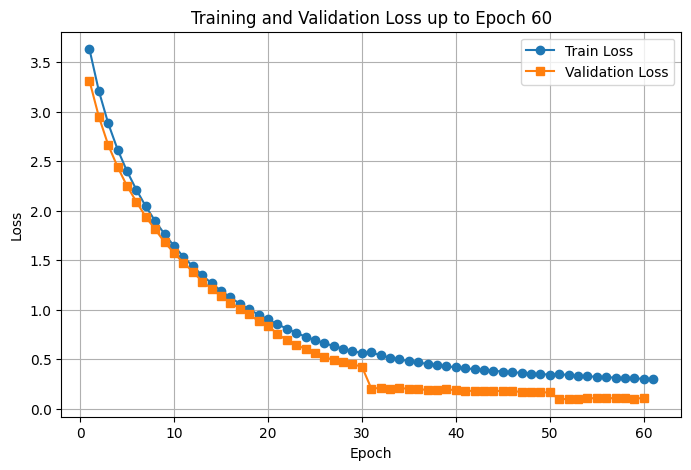

In [25]:
import matplotlib.pyplot as plt 
checkpoint_path = "/kaggle/input/nmt-final/checkpoint_epoch_60.pt"
checkpoint = torch.load(checkpoint_path, map_location="cpu") 

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

train_losses_all = checkpoint["train_losses_all"]
val_losses_all = checkpoint["val_losses_all"]
start_epoch = checkpoint["epoch"]

print(f"Loaded checkpoint from epoch {start_epoch}")

# Printing losses
print(" Training and Validation Losses up to Epoch", start_epoch)
print("=" * 60)
print("Epoch\tTrain Loss\tValidation Loss")
print("-" * 60)
for i, (t, v) in enumerate(zip(train_losses_all, val_losses_all), 1):
    print(f"{i:3d}\t{t:.6f}\t{v:.6f}")

# Ploting
plt.figure(figsize=(8,5))
plt.plot(range(1, len(train_losses_all)+1), train_losses_all, label="Train Loss", marker='o')
plt.plot(range(1, len(val_losses_all)+1), val_losses_all, label="Validation Loss", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training and Validation Loss up to Epoch {start_epoch}")
plt.legend()
plt.grid(True)
plt.show()


In [34]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import random
import torch

model.to(device)
model.eval()
print(f"Loaded model from {checkpoint_path}")

num_samples = 5  # how many examples to print
hypotheses = []
references = []

smoothing = SmoothingFunction().method4  # helps with short sentences

with torch.no_grad():
    src_batch, tgt_batch = next(iter(val_loader))

    for _ in range(num_samples):
        idx = random.randint(0, src_batch.size(0) - 1)
        src_sample = src_batch[idx:idx+1].to(device)
        tgt_sample = tgt_batch[idx:idx+1].to(device)

        # Run greedy decoding
        pred_ids = greedy_decode(model, src_sample, max_len=150, device=device)

        # Filter valid tokens
        vocab_size = sp_tgt.get_piece_size()
        pred_ids_filtered = [i for i in pred_ids if i not in [PAD_IDX, SOS_ID, EOS_ID] and 0 <= i < vocab_size]
        tgt_ids_filtered = [i for i in tgt_sample[0].tolist() if i not in [PAD_IDX, SOS_ID, EOS_ID] and 0 <= i < vocab_size]

        # Decode to text
        pred_text = sp_tgt.decode(pred_ids_filtered)
        tgt_text = sp_tgt.decode(tgt_ids_filtered)

        print(f"Target    : {tgt_text}")
        print(f"Prediction: {pred_text}")
        print("-" * 80)

        # For BLEU computation (split into tokens)
        hypotheses.append(pred_text.split())
        references.append([tgt_text.split()])  # list of list

# Compute BLEU
bleu_score = corpus_bleu(references, hypotheses, smoothing_function=smoothing)
print(f"\nBLEU score: {bleu_score * 100:.2f}")


Loaded model from /kaggle/input/nmt-final/checkpoint_epoch_60.pt
Target    : ye shall bring out of your habitations two wave loaves of two tenth deals: they shall be of fine flour; they shall be baken with leaven; they are the firstfruits unto the lord
Prediction: ye shall bring out of your habitations two wave loaves of two tenth deals: they shall be of fine flour; they shall be baken with leaven; they are the firstfruits unto the lord
--------------------------------------------------------------------------------
Target    : she is a tree of life to them that lay hold upon her: and happy is every one that retaineth her
Prediction: she is a tree of life to them that lay hold upon her: and happy is every one that retaineth her
--------------------------------------------------------------------------------
Target    : behold, the people shall rise up as a great lion, and lift up himself as a young lion: he shall not lie down until he eat of the prey, and drink the blood of the slain
P